<a href="https://colab.research.google.com/github/httperror505/Neural-Network/blob/colab/Market_Basket_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Association Rules:
        antecedents     consequents  antecedent support  consequent support  \
0            (eggs)       (burgers)            0.179709            0.087188   
1         (burgers)          (eggs)            0.087188            0.179709   
2    (french fries)       (burgers)            0.170911            0.087188   
3         (burgers)  (french fries)            0.087188            0.170911   
4   (mineral water)       (burgers)            0.238368            0.087188   
..              ...             ...                 ...                 ...   
89      (spaghetti)      (pancakes)            0.174110            0.095054   
90         (shrimp)     (spaghetti)            0.071457            0.174110   
91      (spaghetti)        (shrimp)            0.174110            0.071457   
92      (spaghetti)      (tomatoes)            0.174110       

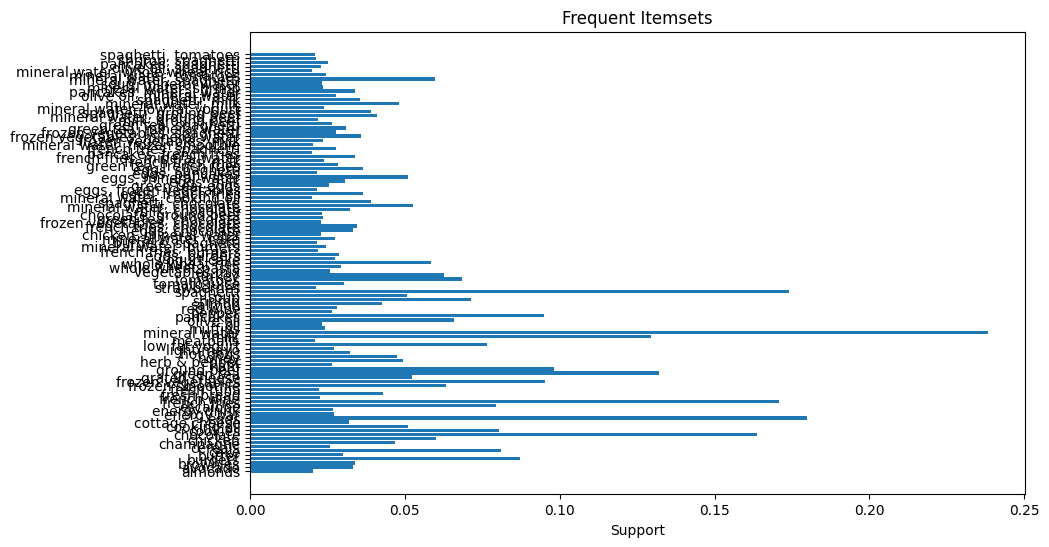

In [ ]:
# Install required libraries
!pip install pandas mlxtend

# Import necessary libraries
import pandas as pd
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset
file_path = '/content/drive/MyDrive/Datasets/Market_Basket_Optimisation.csv'
df = pd.read_csv(file_path, header=None)

# Display the first few rows of the dataframe
df.head()

# Preprocess the data (convert it into the required format for Apriori)
transactions = []
for i in range(len(df)):
    transactions.append([str(df.values[i, j]) for j in range(len(df.columns)) if pd.notna(df.values[i, j])])

# Convert the transactions list into a one-hot encoded dataframe
from mlxtend.preprocessing import TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

# Apply Apriori algorithm to find frequent itemsets
frequent_itemsets = apriori(df_encoded, min_support=0.02, use_colnames=True)

# Generate association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# Display the rules
print("Association Rules:")
print(rules)

# Plot a graph (support vs. itemsets)
plt.figure(figsize=(10, 6))
plt.barh(range(len(frequent_itemsets)), frequent_itemsets['support'], align='center')
plt.yticks(range(len(frequent_itemsets)), frequent_itemsets['itemsets'].apply(lambda x: ', '.join(x)))
plt.xlabel('Support')
plt.title('Frequent Itemsets')
plt.show()

**MARKET BASKET OPTIMIZATION**

Analysis Method Used: Market Basket Optimization